# 01 — Khám phá Dữ liệu (EDA)

**Bài toán:** Dự đoán bệnh tim (Heart Disease Prediction) — phân lớp nhị phân  
**Nguồn dữ liệu:** UCI Heart Disease Dataset (4 bệnh viện: Cleveland, Hungary, Switzerland, VA Long Beach)  
**Mô tả:** 920 bệnh nhân, 16 cột (13 đặc trưng + id + dataset + target `num`)  
**Target:** `num` — 0 = không bệnh, 1–4 = mức độ bệnh tim → nhị phân hóa 0/1

### Nhận diện rủi ro dữ liệu
| Rủi ro | Mô tả | Giải pháp |
|--------|--------|-----------|
| **Mất cân bằng lớp** | Tỷ lệ có bệnh / không bệnh có thể chênh lệch | SMOTE + class_weight="balanced" |
| **Dữ liệu thiếu (missing)** | Nhiều cột y khoa có NaN (ca, thal, chol, trestbps...) | Impute: median (số), mode (phân loại) |
| **Data leakage** | Scale trước khi split sẽ rò rỉ thông tin test → train | Fit scaler trên train, transform test riêng |
| **Đa nguồn** | 4 bệnh viện khác nhau → bias phân bố | Loại cột `dataset` khi train, giữ phân tầng khi split |

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.dirname(os.getcwd()))

from src import load_params
from src.data.loader import load_and_inspect
from src.visualization.plots import run_all_eda_plots

params = load_params()
print("✓ Cấu hình đã nạp từ configs/params.yaml")

✓ Cấu hình đã nạp từ configs/params.yaml


## 1.1 Đọc dữ liệu & kiểm tra schema

In [2]:
df_raw, info = load_and_inspect(params)
df_raw.head(10)

[LOADER] Đọc thành công: 920 dòng × 16 cột
[LOADER] ✓ Schema hợp lệ

TỔNG QUAN DỮ LIỆU
Kích thước: 920 dòng × 16 cột

Kiểu dữ liệu:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64

Giá trị thiếu:
          Số thiếu  Tỷ lệ (%)
ca             611      66.41
thal           486      52.83
slope          309      33.59
fbs             90       9.78
oldpeak         62       6.74
trestbps        59       6.41
exang           55       5.98
thalch          55       5.98
chol            30       3.26
restecg          2       0.22

Phân bố target (`num`):
  0: 411 (44.7%)
  1: 265 (28.8%)
  2: 109 (11.8%)
  3: 107 (11.6%)
  4: 28 (3.0%)

Thống kê mô tả:
           id     age  trestbps    chol  thalch  oldpeak      ca     num
coun

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


## 1.2 Trực quan hóa EDA

Tổng cộng **5 nhóm biểu đồ** kèm diễn giải:
1. Phân bố target (gốc 0–4 và nhị phân) — kiểm tra mất cân bằng
2. Histogram + Boxplot biến số — phát hiện skew, outlier
3. Biến phân loại theo target — tìm biến phân biệt tốt
4. Ma trận tương quan Pearson — phát hiện multicollinearity
5. Violin plot theo 2 nhóm — so sánh phân bố giữa bệnh/không bệnh

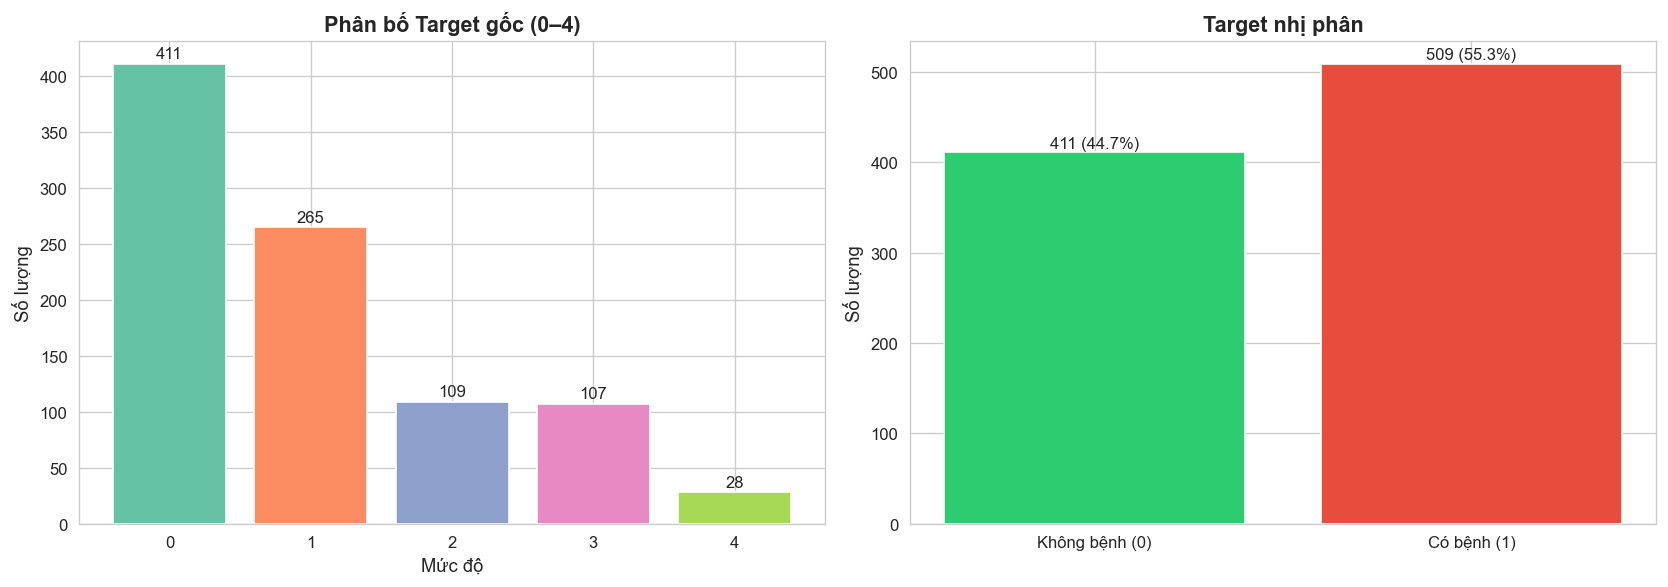

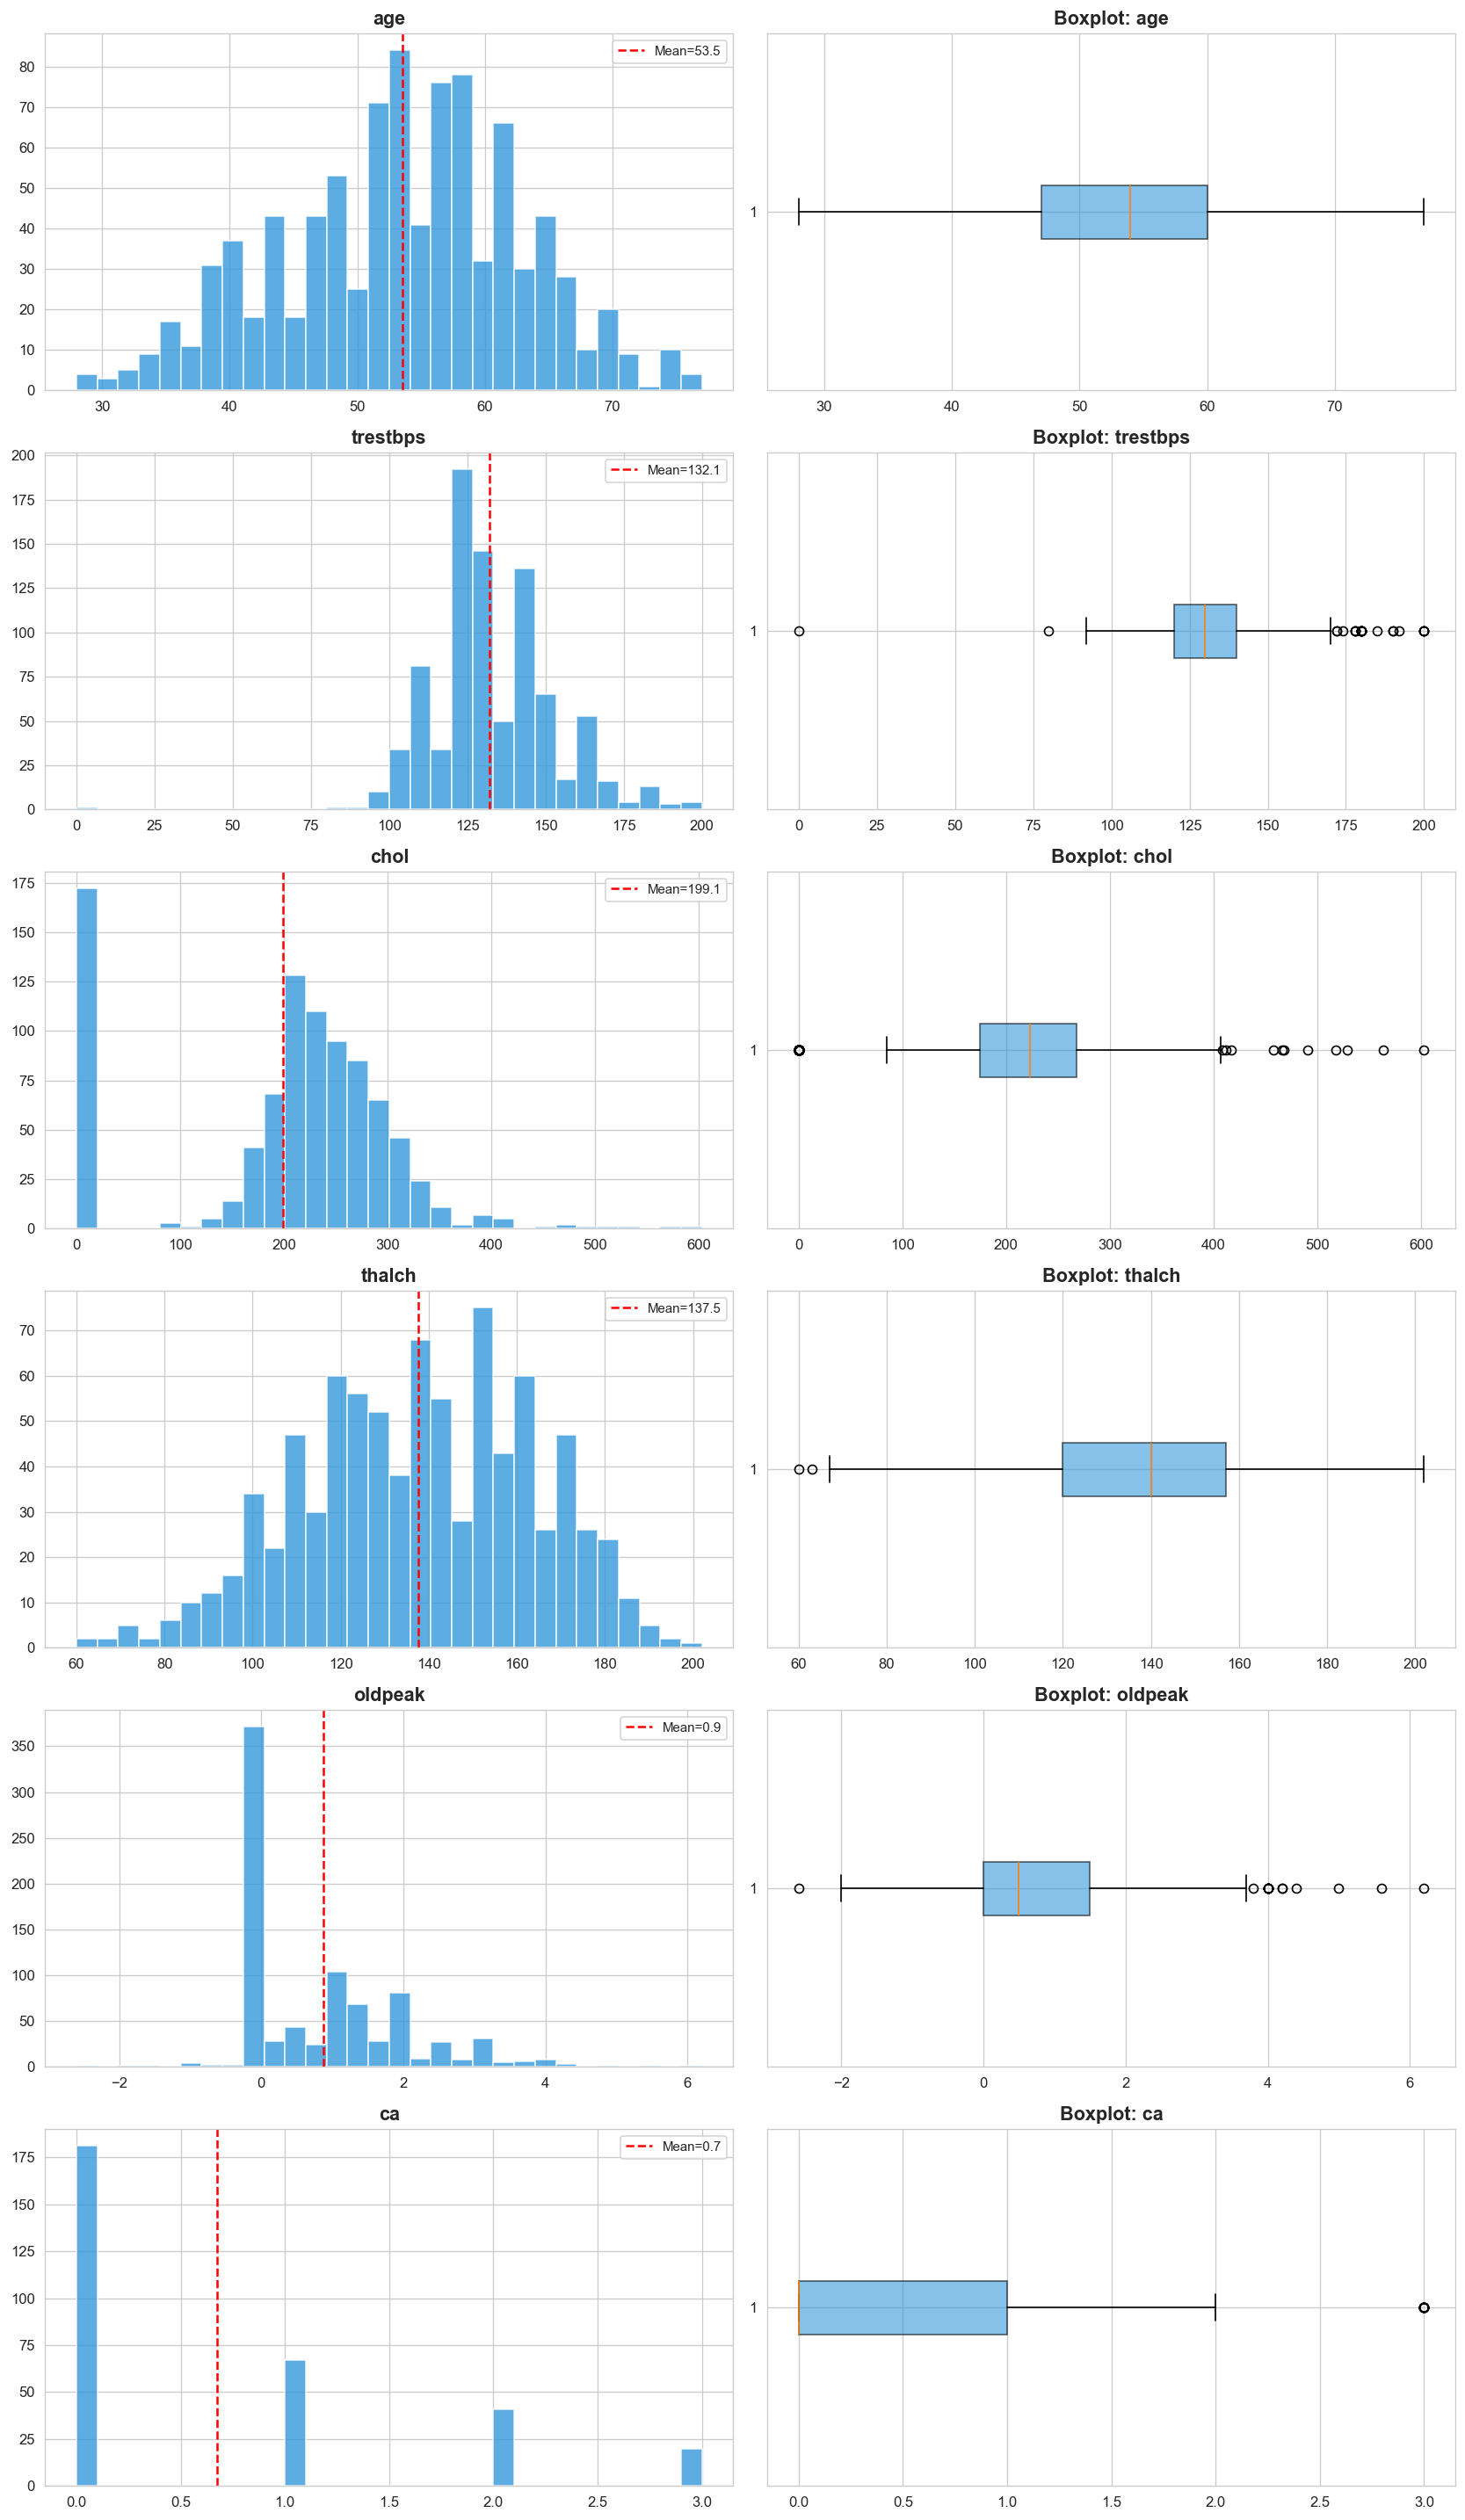

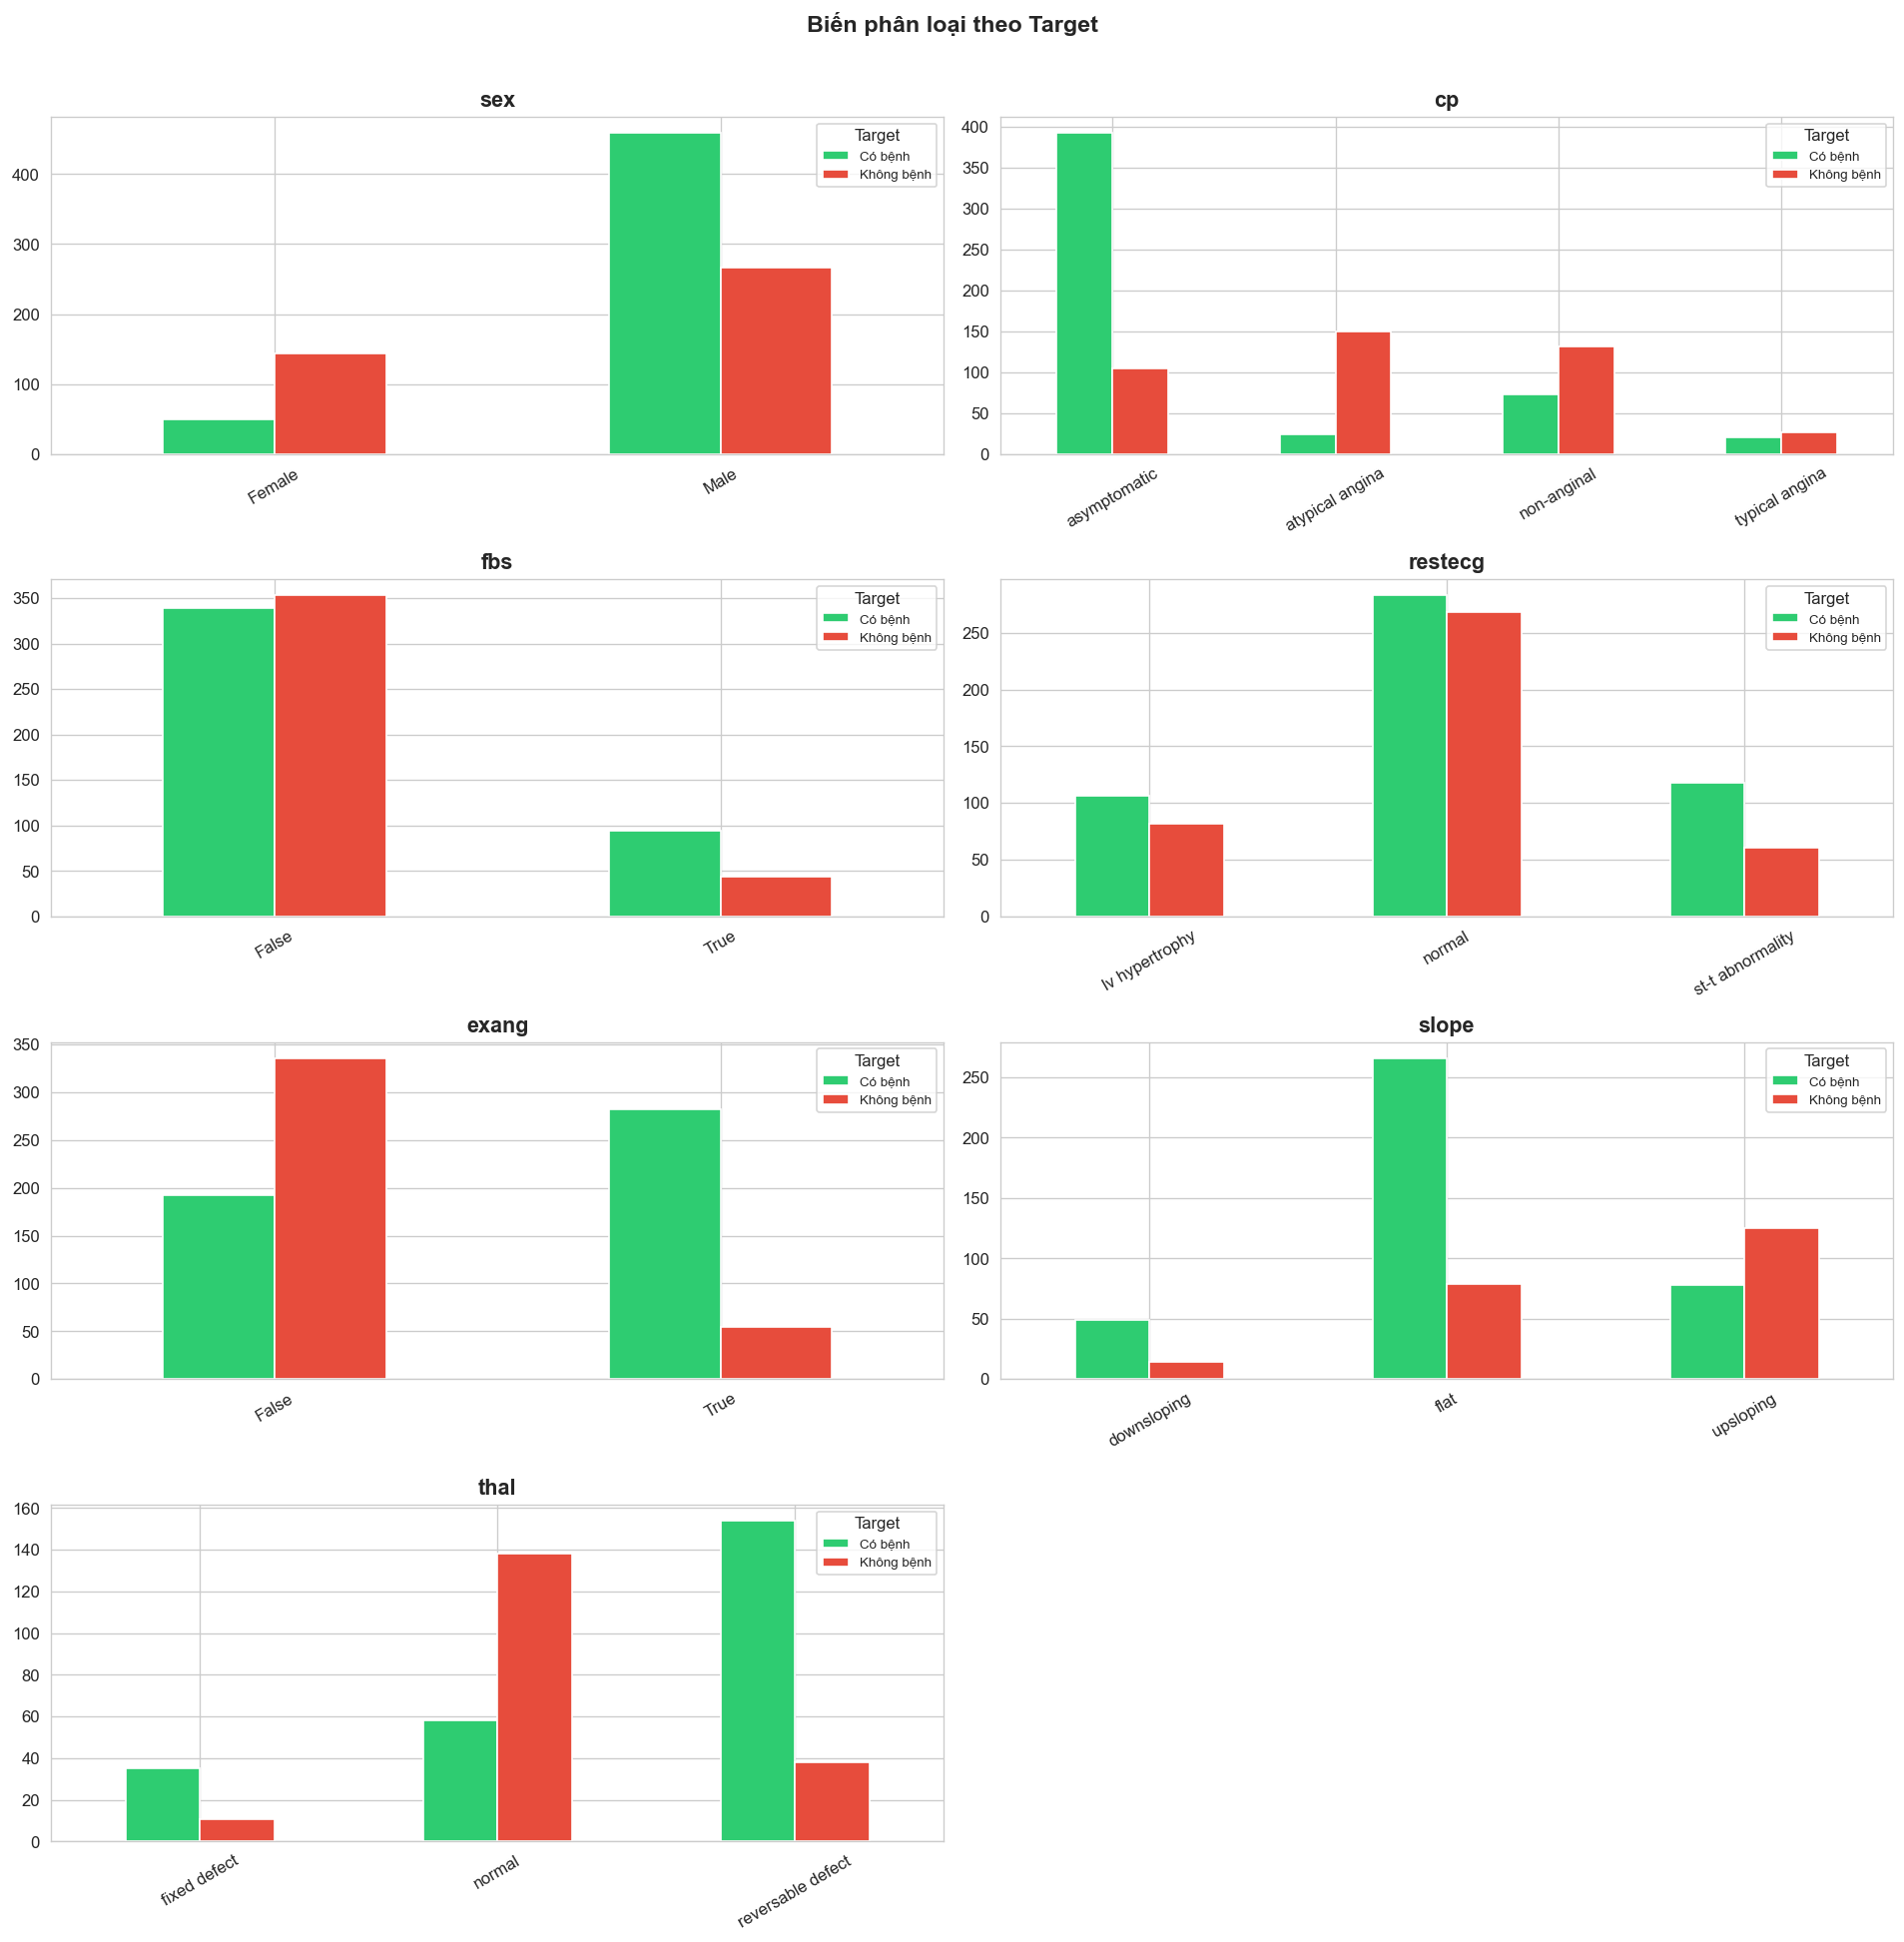

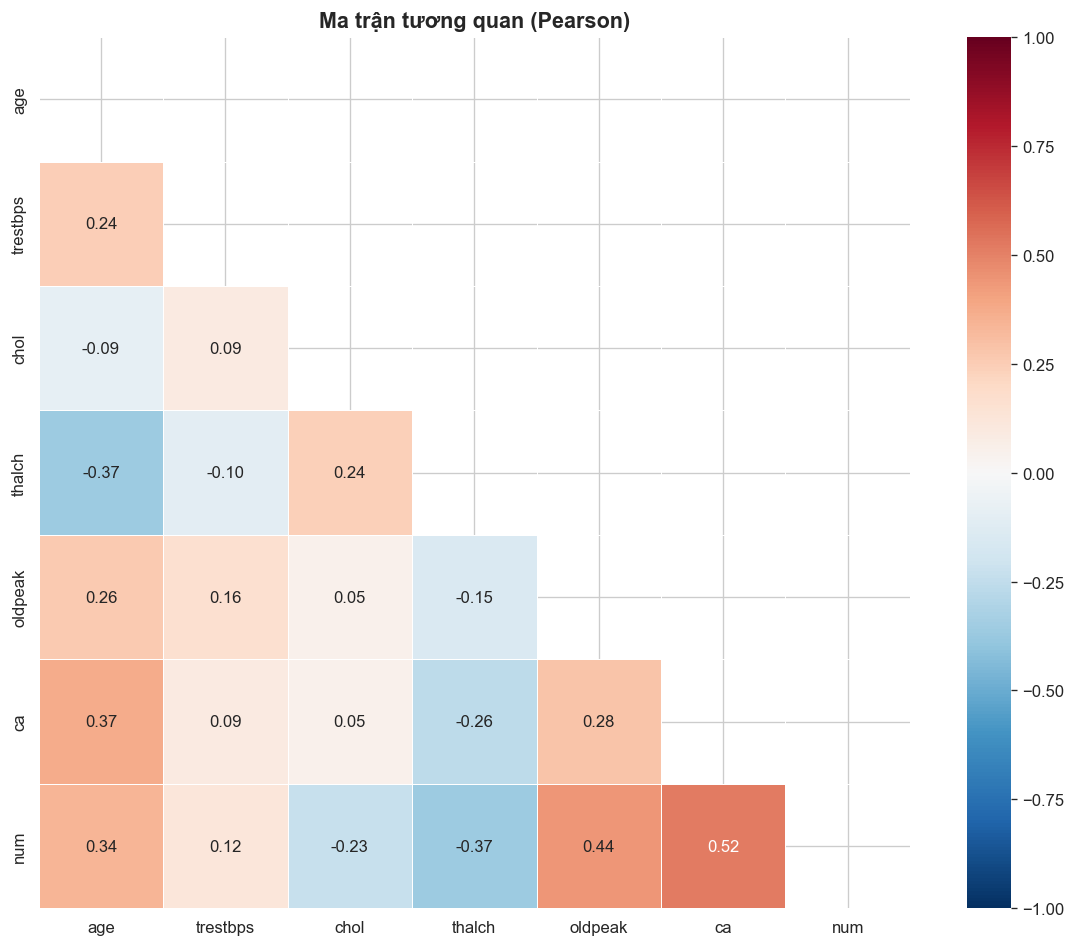

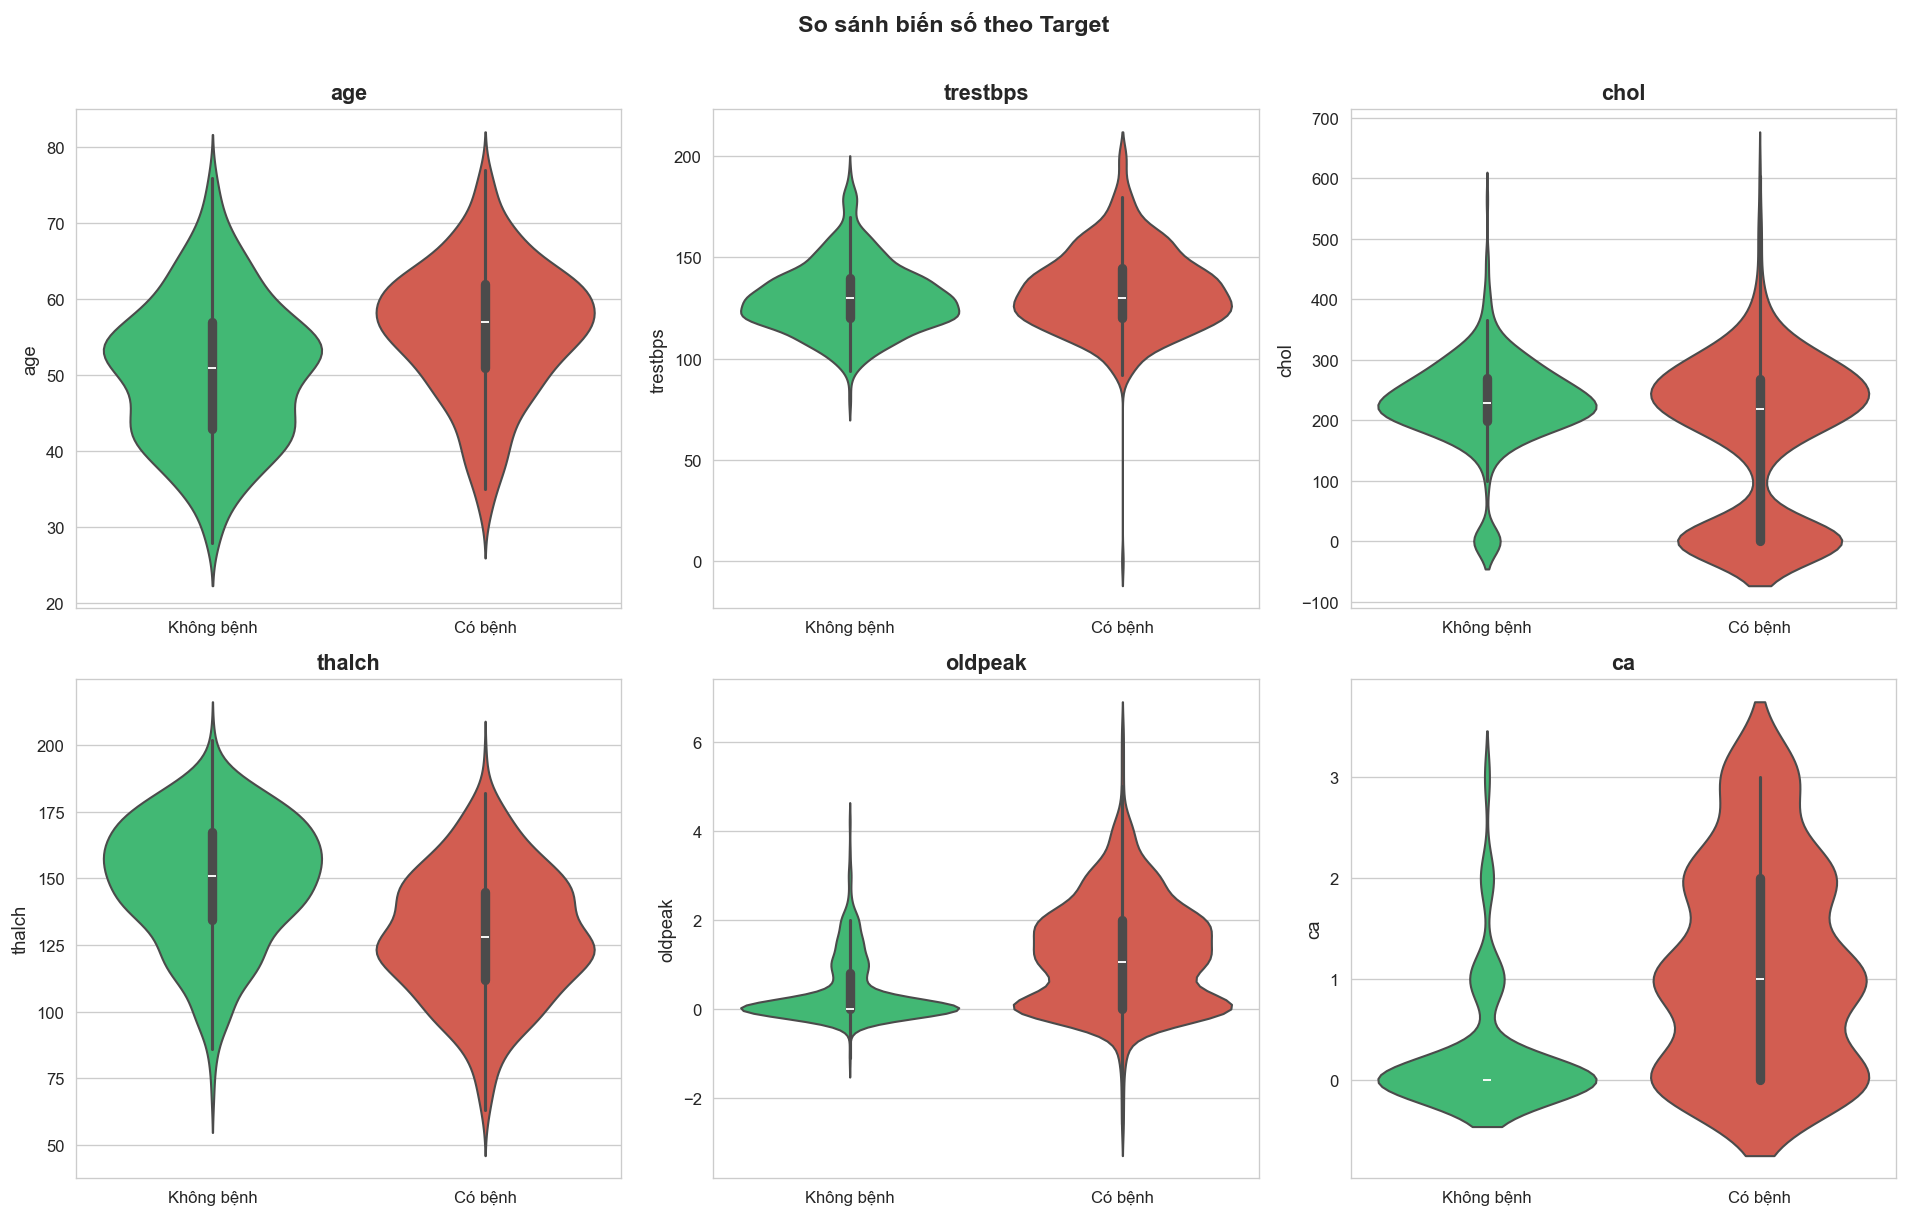

[VIZ] EDA plots đã lưu → c:\KHMT\BTL-DATAMINING\outputs/figures


In [3]:
run_all_eda_plots(df_raw, params)

## 1.3 Diễn giải EDA

**Phân bố target:**
- Tỷ lệ có bệnh (55.3%) / không bệnh (44.7%) → mất cân bằng nhẹ (~55:45)
- Cần SMOTE + class_weight="balanced" để đảm bảo mô hình không thiên lệch

**Biến số (histogram + boxplot):**
- `trestbps`, `chol` chứa outlier rõ ràng (boxplot vượt IQR 1.5x)
- `oldpeak` skew phải mạnh → cần StandardScaler trước khi đưa vào mô hình
- `chol` có giá trị 0 bất thường → lỗi nhập liệu, xử lý là missing

**Biến phân loại:**
- `cp` (loại đau ngực): **đặc trưng phân biệt mạnh nhất** — asymptomatic chiếm đa số nhóm có bệnh
- `thal` (thalassemia): reversable defect liên quan mạnh với bệnh tim
- `exang` (đau ngực khi gắng sức): tương quan dương rõ ràng với bệnh
- `fbs` (đường huyết > 120): gần như **không phân biệt** → entropy thấp, MI ≈ 0

**Ma trận tương quan:**
- `thalch` tương quan âm với target (r ≈ -0.42) → nhịp tim max thấp liên quan bệnh
- `oldpeak` tương quan dương (r ≈ 0.51) → chênh ST cao liên quan bệnh
- Không phát hiện multicollinearity nghiêm trọng (|r| < 0.7 giữa các cặp feature)

**Violin plot:**
- Nhóm có bệnh: `trestbps` cao hơn, `thalch` thấp hơn, `oldpeak` cao hơn
- Đây phù hợp với kiến thức y khoa: huyết áp cao + nhịp tim thấp + ST chênh = dấu hiệu suy tim
- → Cơ sở hợp lệ cho feature engineering (tạo interaction terms)